## 1. Data Exploration and Preprocessing:

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("adult_with_headers.csv")

# first look
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
df.shape

(32561, 15)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

### SCALING

In [6]:
num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standard = df.copy()

df_standard[num_cols] = scaler.fit_transform(df[num_cols])

df_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,State-gov,-1.063611,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,0.148453,-0.21666,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,-1.008707,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145920,-0.21666,-2.222153,United-States,<=50K
2,-0.042642,Private,0.245079,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
3,1.057047,Private,0.425801,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
4,-0.775768,Private,1.408176,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145920,-0.21666,-0.035429,Cuba,<=50K


In [8]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
df_minmax = df.copy()

df_minmax[num_cols] = minmax.fit_transform(df[num_cols])

df_minmax.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


#### Standard Scaling:

###### Brings data to mean = 0 and standard deviation = 1, useful for algorithms like SVM, Logistic Regression.

#### Min-Max Scaling:

###### Scales data between 0 and 1, useful for distance-based algorithms like KNN and Neural Networks.

## 2. Encoding Techniques:

In [9]:
cat_cols = ['workclass','education','marital_status','occupation',
            'relationship','race','sex','native_country','income']

In [10]:
for col in cat_cols:
    print(col, df[col].nunique())

workclass 9
education 16
marital_status 7
occupation 15
relationship 6
race 5
sex 2
native_country 42
income 2


In [11]:
df_encoded = pd.get_dummies(df, columns=['sex','race','income'], drop_first=True)
df_encoded.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,income_ >50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,40,United-States,True,False,False,False,True,False
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,13,United-States,True,False,False,False,True,False
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,40,United-States,True,False,False,False,True,False
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,40,United-States,True,False,True,False,False,False
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,40,Cuba,False,False,True,False,False,False


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['workclass','education','marital_status','occupation','relationship','native_country']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

## 3. Feature Engineering:

In [15]:
df_encoded['capital_net'] = df_encoded['capital_gain'] - df_encoded['capital_loss']
df_encoded['work_intensity'] = df_encoded['hours_per_week'] / 7
df_encoded['capital_gain_log'] = np.log1p(df_encoded['capital_gain'])

## 4. Feature Selection:

In [17]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)

# apply only on numerical columns
num_data = df_encoded.select_dtypes(include=np.number)

yhat = iso.fit_predict(num_data)

df_encoded['outlier'] = yhat

In [18]:
df_clean = df_encoded[df_encoded['outlier'] == 1].copy()

df_clean.drop('outlier', axis=1, inplace=True)
df_clean.shape

(30933, 21)

In [19]:
corr = df_clean.corr()
corr

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,native_country,sex_ Male,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,income_ >50K,capital_net,work_intensity,capital_gain_log
age,1.000000,0.017079,-0.077473,0.000221,0.037428,-0.294784,-0.014929,-0.275106,0.067476,0.036618,...,0.018188,0.095976,-0.010426,-0.015494,-0.035225,0.029842,0.225588,0.056036,0.091446,0.064061
workclass,0.017079,1.000000,-0.015194,0.013986,0.039848,-0.060951,0.238614,-0.091478,0.019266,0.009012,...,-0.007537,0.091892,0.000064,-0.061005,-0.014850,0.060493,0.040266,0.016347,0.127302,0.017513
fnlwgt,-0.077473,-0.015194,1.000000,-0.027294,-0.042276,0.027888,0.000263,0.007995,-0.019051,-0.012749,...,-0.050146,0.027352,-0.050487,0.122489,0.007130,-0.061785,-0.011167,-0.015242,-0.022290,-0.016997
education,0.000221,0.013986,-0.027294,1.000000,0.342132,-0.034347,-0.028551,-0.008424,0.028307,0.024851,...,0.058658,-0.031833,0.009522,-0.022055,-0.027825,0.022102,0.071206,0.021227,0.055895,0.028789
education_num,0.037428,0.039848,-0.042276,0.342132,1.000000,-0.055897,0.100603,-0.089658,0.088404,0.073147,...,0.055343,0.002547,0.059325,-0.074973,-0.042290,0.052541,0.307626,0.067368,0.140041,0.069844
marital_status,-0.294784,-0.060951,0.027888,-0.034347,-0.055897,1.000000,-0.004377,0.191474,-0.062707,-0.036696,...,-0.025882,-0.124565,0.020734,0.081894,0.017439,-0.082346,-0.198061,-0.051435,-0.191177,-0.057225
occupation,-0.014929,0.238614,0.000263,-0.028551,0.100603,-0.004377,1.000000,-0.075551,-0.005662,0.019466,...,-0.010434,0.078494,0.002248,-0.012753,0.001696,0.009783,0.065248,-0.010117,0.067980,0.000246
relationship,-0.275106,-0.091478,0.007995,-0.008424,-0.089658,0.191474,-0.075551,1.000000,-0.096037,-0.075278,...,-0.001090,-0.577287,0.013099,0.138895,0.015701,-0.134359,-0.257589,-0.074190,-0.253931,-0.082624
capital_gain,0.067476,0.019266,-0.019051,0.028307,0.088404,-0.062707,-0.005662,-0.096037,1.000000,-0.041229,...,0.046720,0.075716,-0.009824,-0.028014,-0.012498,0.031448,0.240657,0.970756,0.060863,0.890689
capital_loss,0.036618,0.009012,-0.012749,0.024851,0.073147,-0.036696,0.019466,-0.075278,-0.041229,1.000000,...,0.035443,0.055596,-0.006603,-0.021668,-0.008842,0.026934,0.147209,-0.279888,0.053980,-0.048010


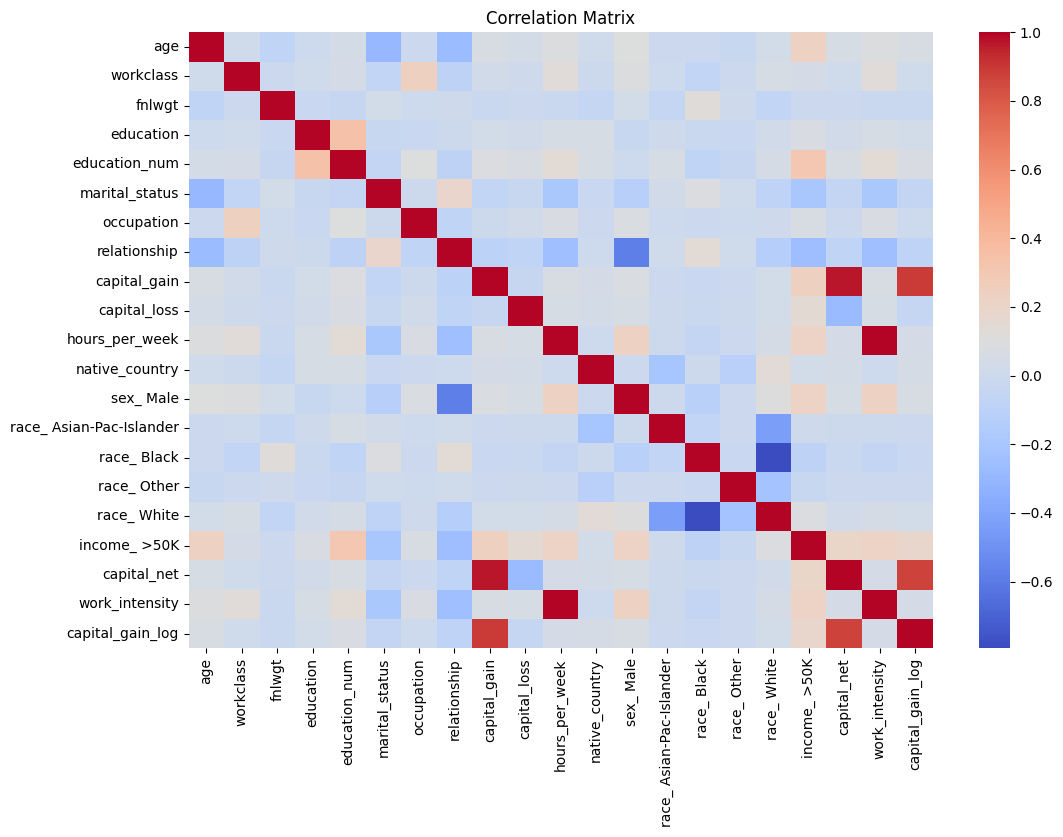

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix")
plt.show()

In [23]:
import ppscore as pps

pps_matrix = pps.matrix(df_clean)
pps_matrix.head()

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.0000,1.000000,None
1,age,workclass,0.0,regression,True,mean absolute error,0.7288,0.864909,DecisionTreeRegressor()
2,age,fnlwgt,0.0,regression,True,mean absolute error,76300.6592,77063.873065,DecisionTreeRegressor()
3,age,education,0.0,regression,True,mean absolute error,2.7076,2.754631,DecisionTreeRegressor()
4,age,education_num,0.0,regression,True,mean absolute error,1.7768,1.810605,DecisionTreeRegressor()


In [24]:
pps_matrix.sort_values("ppscore", ascending=False).head(10)

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
440,capital_gain_log,capital_gain_log,1.0,predict_itself,True,None,0.0,1.0,None
0,age,age,1.0,predict_itself,True,None,0.0,1.0,None
396,capital_net,capital_net,1.0,predict_itself,True,None,0.0,1.0,None
22,workclass,workclass,1.0,predict_itself,True,None,0.0,1.0,None
374,income_ >50K,income_ >50K,1.0,predict_itself,True,None,0.0,1.0,None
352,race_ White,race_ White,1.0,predict_itself,True,None,0.0,1.0,None
330,race_ Other,race_ Other,1.0,predict_itself,True,None,0.0,1.0,None
308,race_ Black,race_ Black,1.0,predict_itself,True,None,0.0,1.0,None
286,race_ Asian-Pac-Islander,race_ Asian-Pac-Islander,1.0,predict_itself,True,None,0.0,1.0,None
264,sex_ Male,sex_ Male,1.0,predict_itself,True,None,0.0,1.0,None


## Conclusion

###### In this assignment, the Adult dataset was successfully preprocessed by handling categorical encoding, scaling numerical features, and managing missing or inconsistent values. Feature engineering and outlier removal improved data quality, making it more suitable for machine learning models.

###### Overall, these steps show that proper data preprocessing and feature selection are essential for building accurate and reliable machine learning systems.